# 🌿 AgroSat — Classificação de Vegetação Agrícola
### Global Solution 2026/1 — FIAP | AI & Chatbot

| Integrante | RM | Turma |
|---|---|---|
| Gustavo Rodrigues Siciliano | RM568419 | 1TDS Agosto |
| Gustavo de Jesus Silva | RM567926 | 1TDS Agosto |
| Samuel Keniti Kina de Lima | RM567614 | 1TDS Agosto |

**GitHub:** https://github.com/GustavoSiciliano/Global-Solution-2026

---

## Sobre este notebook

Modelo 1 do pipeline AgroSat: classifica o estado da vegetação agrícola com dados satelitais da NASA.

- 🟢 **SAUDAVEL** — boa cobertura vegetal, sem estresse hídrico
- 🟡 **EM_ESTRESSE** — sinais de degradação, requer monitoramento
- 🔴 **CRITICO** — risco alto de perda de colheita

**Algoritmo:** Random Forest Classifier | **Dataset:** 300 registros, 10 regiões agrícolas brasileiras

---
## 1. Imports e Carregamento dos Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix
)
import joblib
import warnings
import os
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
print('Bibliotecas carregadas!')

Bibliotecas carregadas!


In [2]:
# Resolve caminho relativo ao notebook independente de onde o Jupyter foi aberto
BASE_DIR = Path('__file__').resolve().parent if Path('__file__').exists() else Path().resolve()
while not (BASE_DIR / 'data').exists() and BASE_DIR != BASE_DIR.parent:
    BASE_DIR = BASE_DIR.parent

df = pd.read_csv(BASE_DIR / 'data' / 'agrosat_dataset.csv')
print(f'Shape: {df.shape}')
print(f'Colunas: {list(df.columns)}')
print(f'Nulos: {df.isnull().sum().sum()}')
df.head(10)

Shape: (300, 9)
Colunas: ['regiao', 'ndvi', 'temperatura', 'precipitacao', 'umidade', 'dias_sem_chuva', 'radiacao_solar', 'status_vegetacao', 'risco_hidrico']
Nulos: 0


,regiao,ndvi,temperatura,precipitacao,umidade,dias_sem_chuva,radiacao_solar,status_vegetacao,risco_hidrico
0,Passo Fundo/RS,-0.0285,38.46,1.79,18.92,42,23.41,CRITICO,95.92
1,Uberlândia/MG,0.3164,33.05,14.20,30.02,17,19.28,EM_ESTRESSE,40.80
2,Palmas/TO,0.8141,19.67,28.15,72.82,5,10.91,SAUDAVEL,14.75
3,Barreiras/BA,0.3135,32.25,4.22,31.95,9,24.60,EM_ESTRESSE,49.03
4,Santarém/PA,0.8395,23.28,20.49,77.33,2,19.09,SAUDAVEL,7.44
5,Lucas do Rio Verde/MT,0.3603,31.97,2.41,55.27,17,24.58,EM_ESTRESSE,61.91
6,Uberlândia/MG,0.4510,34.73,12.98,52.42,10,22.11,EM_ESTRESSE,64.43
7,Palmas/TO,0.6578,18.19,34.05,73.82,2,11.99,SAUDAVEL,19.52
8,Rio Verde/GO,0.1539,39.40,2.55,18.99,20,23.44,CRITICO,74.84
9,Rondonópolis/MT,0.3797,31.93,6.98,59.15,8,23.33,EM_ESTRESSE,51.27


In [3]:
df.describe().round(2)

,ndvi,temperatura,precipitacao,umidade,dias_sem_chuva,radiacao_solar,risco_hidrico
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,0.45,30.29,16.93,49.23,14.67,20.58,45.82
std,0.29,6.04,17.87,25.31,13.19,5.47,30.15
min,-0.10,18.06,0.03,10.00,0.00,10.03,0.00
25%,0.21,26.06,2.43,25.78,4.00,16.58,16.83
50%,0.46,31.11,9.72,48.96,10.00,20.56,42.70
75%,0.67,34.76,26.77,73.50,24.00,24.63,72.11
max,0.95,39.96,59.86,94.92,44.00,29.98,100.00


---
## 2. Análise Exploratória dos Dados (EDA)

> Entender distribuição das classes, correlações e comportamento de cada variável antes de treinar o modelo.

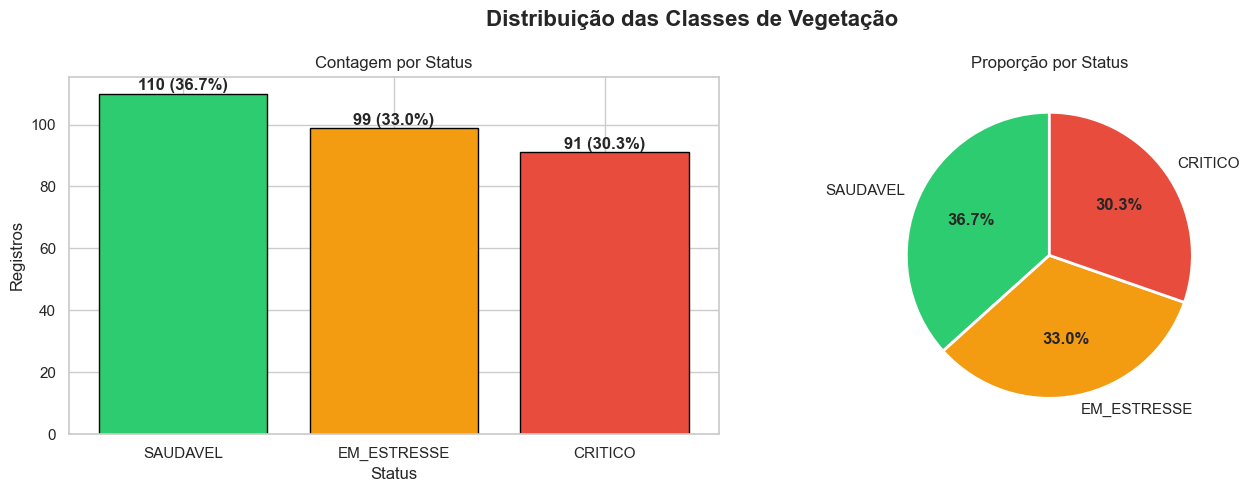

In [4]:
# Distribuição das classes
cores = {'SAUDAVEL': '#2ecc71', 'EM_ESTRESSE': '#f39c12', 'CRITICO': '#e74c3c'}
contagem = df['status_vegetacao'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuição das Classes de Vegetação', fontsize=16, fontweight='bold')
bars = axes[0].bar(contagem.index, contagem.values,
                   color=[cores[s] for s in contagem.index], edgecolor='black')
axes[0].set_title('Contagem por Status')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Registros')
for bar, v in zip(bars, contagem.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 1,
                f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
wedges, texts, autotexts = axes[1].pie(
    contagem.values, labels=contagem.index,
    colors=[cores[s] for s in contagem.index],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[1].set_title('Proporção por Status')
plt.tight_layout()
plt.show()

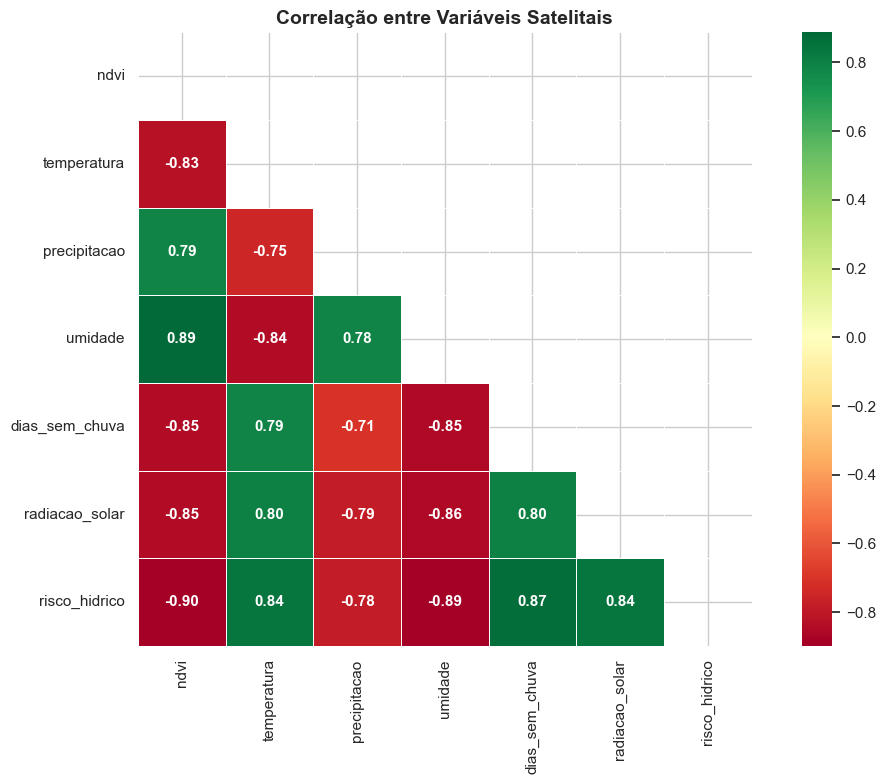

NDVI negativo com temperatura e dias_sem_chuva confirma que calor e seca degradam a vegetação.


In [5]:
# Heatmap de correlação
fig, ax = plt.subplots(figsize=(11, 8))
features_num = ['ndvi','temperatura','precipitacao','umidade','dias_sem_chuva','radiacao_solar','risco_hidrico']
corr = df[features_num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, mask=mask, ax=ax,
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Correlação entre Variáveis Satelitais', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('NDVI negativo com temperatura e dias_sem_chuva confirma que calor e seca degradam a vegetação.')

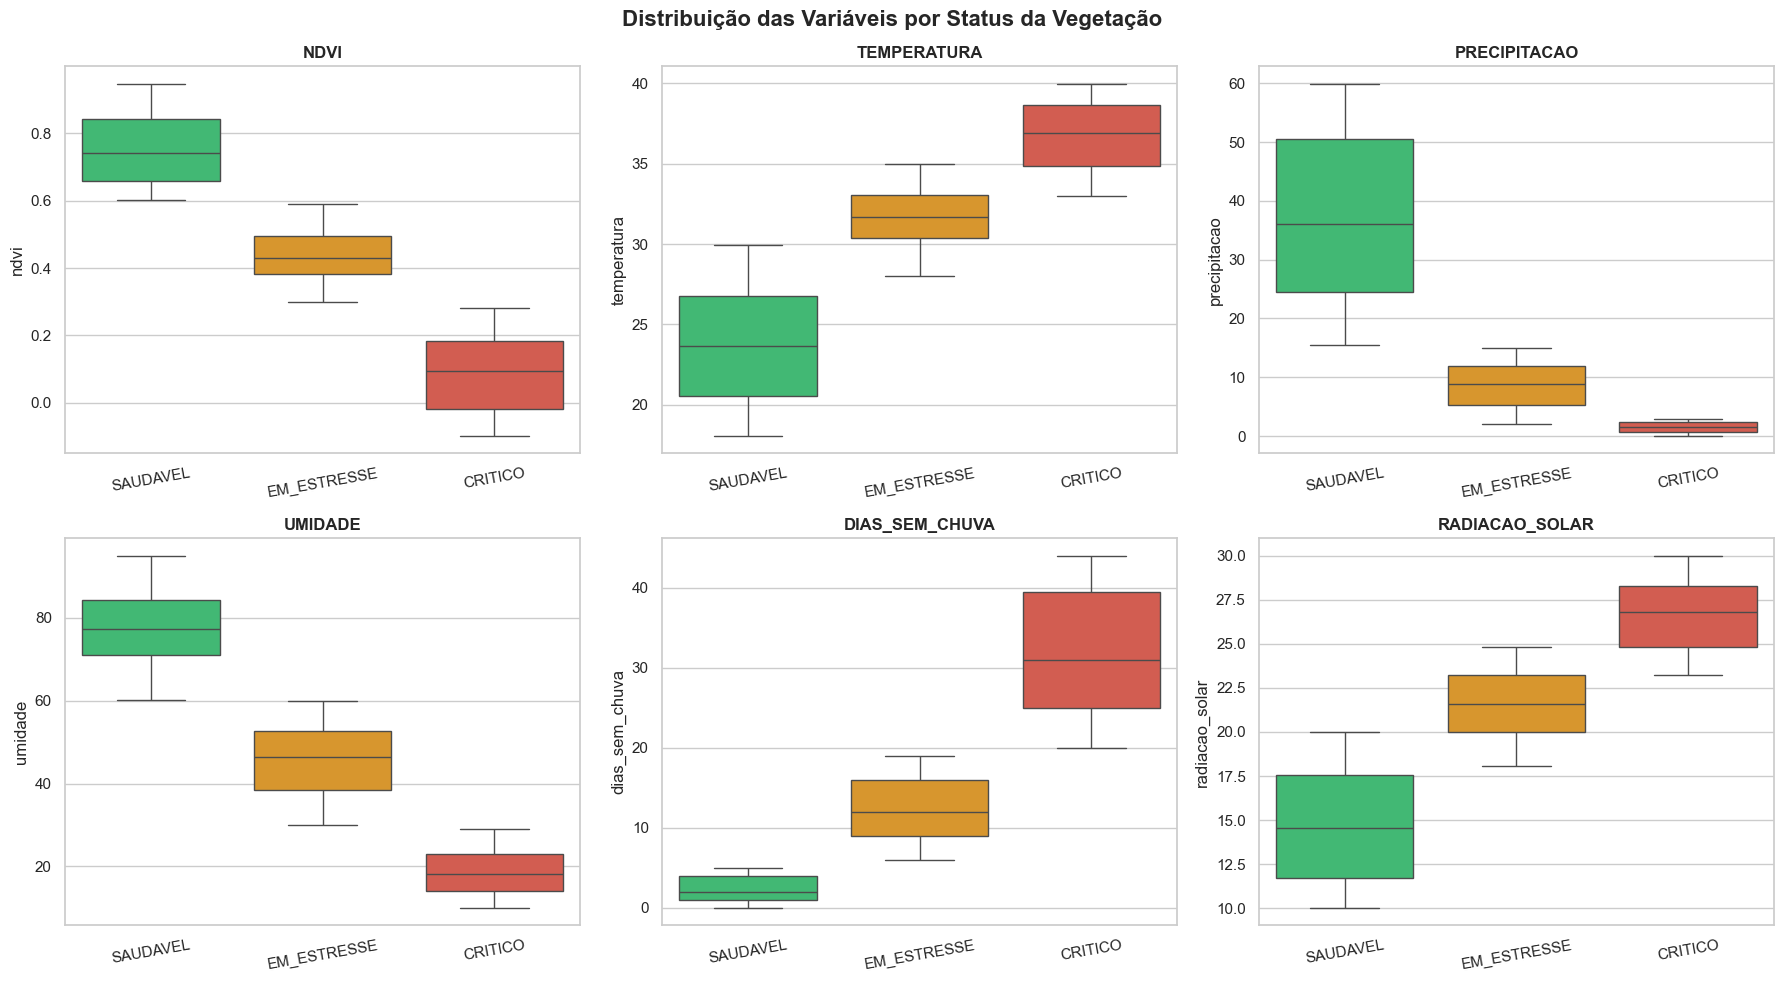

NDVI alto = SAUDAVEL. Temperatura alta + dias_sem_chuva alto = CRITICO.


In [6]:
# Boxplots de todas as variáveis por status
variaveis = ['ndvi','temperatura','precipitacao','umidade','dias_sem_chuva','radiacao_solar']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribuição das Variáveis por Status da Vegetação', fontsize=16, fontweight='bold')
axes = axes.flatten()
ordem = ['SAUDAVEL','EM_ESTRESSE','CRITICO']
palette = {'SAUDAVEL': '#2ecc71', 'EM_ESTRESSE': '#f39c12', 'CRITICO': '#e74c3c'}
for ax, var in zip(axes, variaveis):
    sns.boxplot(data=df, x='status_vegetacao', y=var, order=ordem, palette=palette, ax=ax)
    ax.set_title(var.upper(), fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.show()
print('NDVI alto = SAUDAVEL. Temperatura alta + dias_sem_chuva alto = CRITICO.')

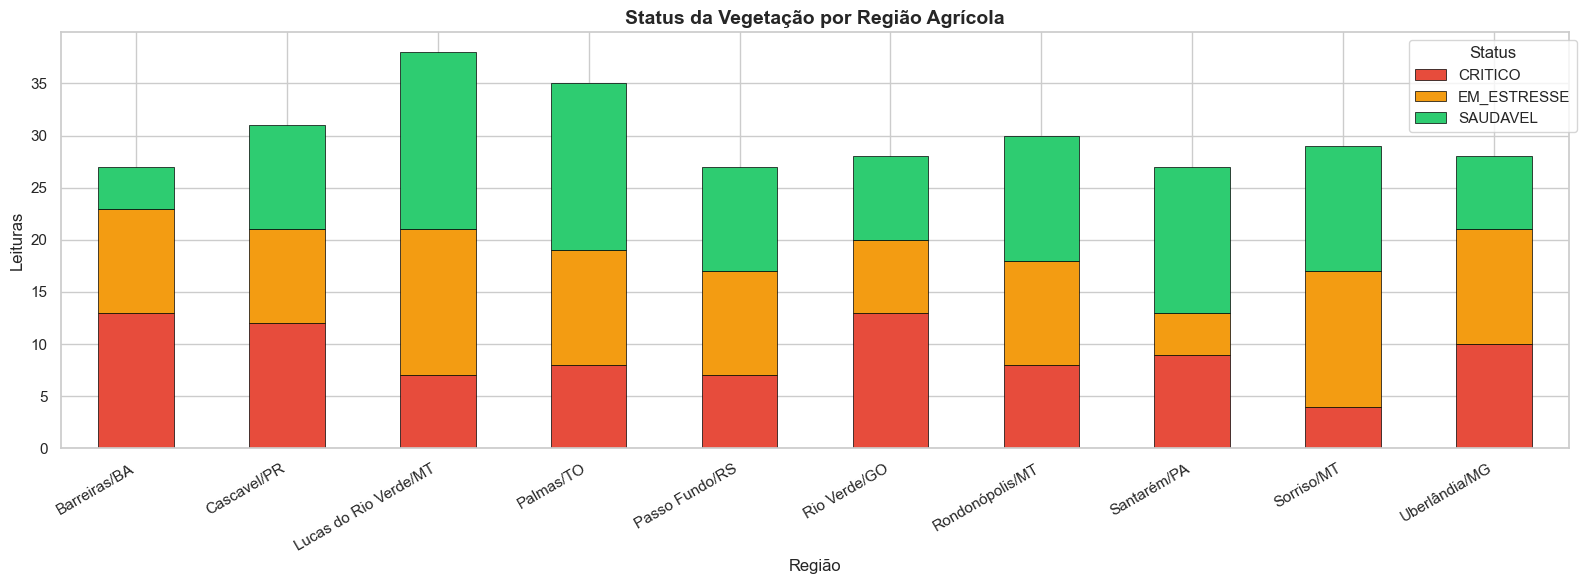

In [7]:
# Status por região agrícola
fig, ax = plt.subplots(figsize=(16, 6))
df_contagem = df.groupby(['regiao','status_vegetacao']).size().unstack(fill_value=0)
df_contagem[['CRITICO','EM_ESTRESSE','SAUDAVEL']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['#e74c3c','#f39c12','#2ecc71'], edgecolor='black', linewidth=0.5)
ax.set_title('Status da Vegetação por Região Agrícola', fontsize=14, fontweight='bold')
ax.set_xlabel('Região')
ax.set_ylabel('Leituras')
ax.legend(title='Status', bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 3. Pré-processamento

In [8]:
FEATURES = ['ndvi','temperatura','precipitacao','umidade','dias_sem_chuva','radiacao_solar']
X = df[FEATURES]
le = LabelEncoder()
y = le.fit_transform(df['status_vegetacao'])
print(f'Features: {FEATURES}')
print(f'Classes: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Features: ['ndvi', 'temperatura', 'precipitacao', 'umidade', 'dias_sem_chuva', 'radiacao_solar']
Classes: {'CRITICO': np.int64(0), 'EM_ESTRESSE': np.int64(1), 'SAUDAVEL': np.int64(2)}


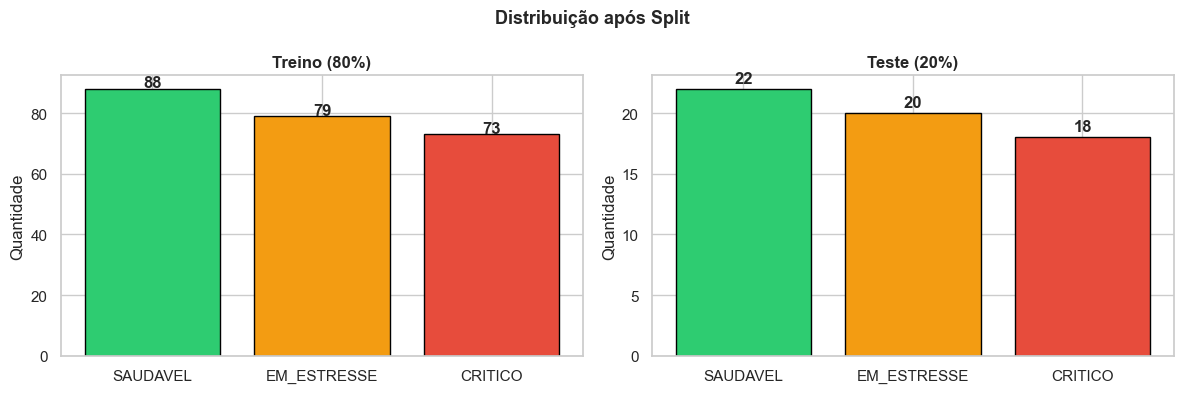

Treino: 240 | Teste: 60


In [9]:
# Divisão 80/20 com stratify para manter proporção das classes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, dados, titulo in zip(axes, [y_train, y_test], ['Treino (80%)', 'Teste (20%)']):
    cnt = pd.Series(le.inverse_transform(dados)).value_counts()
    ax.bar(cnt.index, cnt.values, color=[cores[s] for s in cnt.index], edgecolor='black')
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('Quantidade')
    for i, v in enumerate(cnt.values):
        ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.suptitle('Distribuição após Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Treino: {len(X_train)} | Teste: {len(X_test)}')

---
## 4. Treinamento

> Random Forest: conjunto de árvores de decisão que votam para definir a classe final.

In [10]:
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
print(f'Modelo treinado! Árvores: {clf.n_estimators}')

Modelo treinado! Árvores: 100


---
## 5. Avaliação de Desempenho

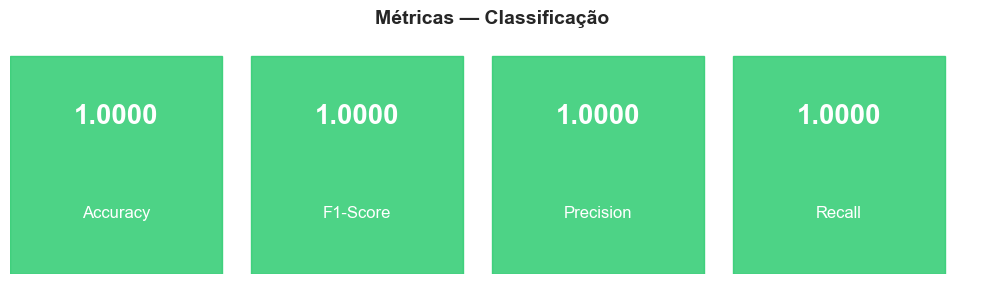

In [11]:
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
metricas = [('Accuracy', acc), ('F1-Score', f1), ('Precision', prec), ('Recall', rec)]
for i, (nome, valor) in enumerate(metricas):
    cor = '#2ecc71' if valor >= 0.9 else '#f39c12' if valor >= 0.7 else '#e74c3c'
    ax.add_patch(plt.Rectangle((i*0.25, 0), 0.22, 0.9, color=cor, alpha=0.85, transform=ax.transAxes))
    ax.text(i*0.25+0.11, 0.65, f'{valor:.4f}', ha='center', va='center',
            fontsize=20, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(i*0.25+0.11, 0.25, nome, ha='center', va='center',
            fontsize=12, color='white', transform=ax.transAxes)
ax.set_title('Métricas — Classificação', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
print('Relatório completo por classe:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Relatório completo por classe:
              precision    recall  f1-score   support

     CRITICO       1.00      1.00      1.00        18
 EM_ESTRESSE       1.00      1.00      1.00        20
    SAUDAVEL       1.00      1.00      1.00        22

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



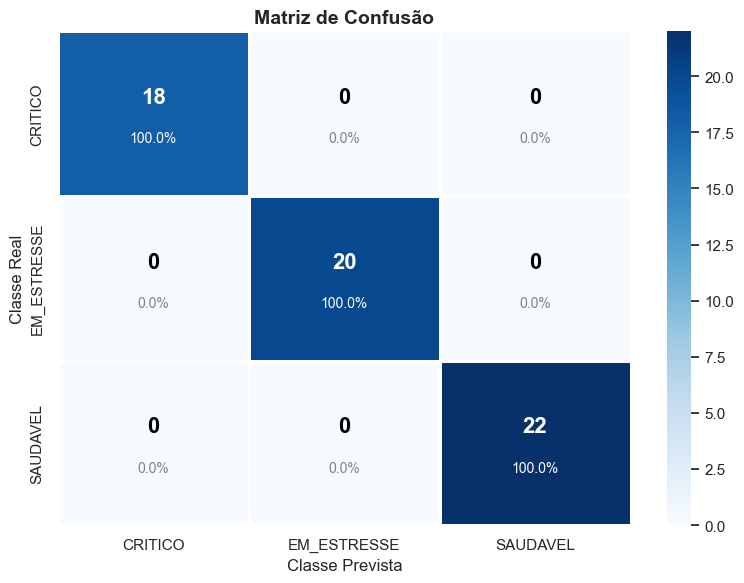

Diagonal principal = acertos. Fora da diagonal = erros.


In [13]:
# Matriz de confusão
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=le.classes_,
            yticklabels=le.classes_, ax=ax, linewidths=1, linecolor='white')
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        ax.text(j+0.5, i+0.4, str(cm[i,j]), ha='center', va='center',
                fontsize=16, fontweight='bold',
                color='white' if cm[i,j] > cm.max()/2 else 'black')
        ax.text(j+0.5, i+0.65, f'{cm_pct[i,j]:.1f}%', ha='center', va='center',
                fontsize=10, color='white' if cm[i,j] > cm.max()/2 else 'gray')
ax.set_title('Matriz de Confusão', fontsize=14, fontweight='bold')
ax.set_ylabel('Classe Real')
ax.set_xlabel('Classe Prevista')
plt.tight_layout()
plt.show()
print('Diagonal principal = acertos. Fora da diagonal = erros.')

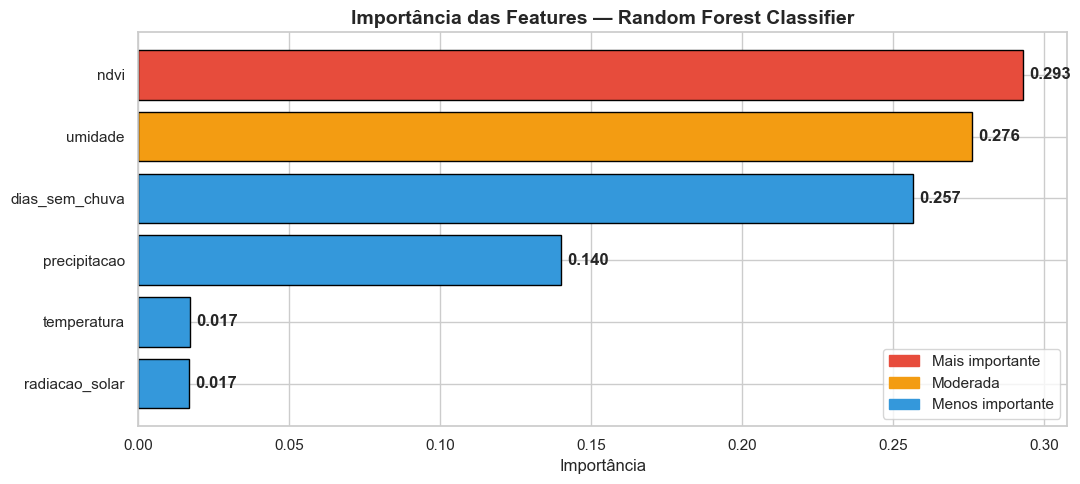

Feature mais importante: ndvi


In [14]:
# Feature importance
fig, ax = plt.subplots(figsize=(11, 5))
importances = pd.Series(clf.feature_importances_, index=FEATURES).sort_values()
cores_imp = ['#e74c3c' if v == importances.max() else
             '#f39c12' if v >= importances.quantile(0.66) else '#3498db'
             for v in importances.values]
bars = ax.barh(importances.index, importances.values, color=cores_imp, edgecolor='black')
for bar, v in zip(bars, importances.values):
    ax.text(v+0.002, bar.get_y()+bar.get_height()/2, f'{v:.3f}', va='center', fontweight='bold')
ax.set_title('Importância das Features — Random Forest Classifier', fontsize=14, fontweight='bold')
ax.set_xlabel('Importância')
patches = [
    mpatches.Patch(color='#e74c3c', label='Mais importante'),
    mpatches.Patch(color='#f39c12', label='Moderada'),
    mpatches.Patch(color='#3498db', label='Menos importante')
]
ax.legend(handles=patches)
plt.tight_layout()
plt.show()
print(f'Feature mais importante: {importances.idxmax()}')

In [15]:
# Testes manuais
amostras = [
    {'regiao': 'Rondonópolis/MT', 'ndvi': 0.21, 'temperatura': 35.8,
     'precipitacao': 0.0, 'umidade': 28.0, 'dias_sem_chuva': 30, 'radiacao_solar': 26.1},
    {'regiao': 'Cascavel/PR', 'ndvi': 0.78, 'temperatura': 22.1,
     'precipitacao': 35.0, 'umidade': 80.0, 'dias_sem_chuva': 0, 'radiacao_solar': 15.3}
]
print('Testes manuais:\n')
for a in amostras:
    regiao = a.pop('regiao')
    entrada = pd.DataFrame([a])
    pred = clf.predict(entrada)
    proba = clf.predict_proba(entrada)
    label = le.inverse_transform(pred)[0]
    print(f'  {regiao} → {label} ({max(proba[0])*100:.1f}% confiança)')

Testes manuais:

  Rondonópolis/MT → CRITICO (100.0% confiança)
  Cascavel/PR → SAUDAVEL (100.0% confiança)


In [16]:
os.makedirs(BASE_DIR / 'pickles', exist_ok=True)
joblib.dump(clf, BASE_DIR / 'pickles' / 'modelo_classificacao.pickle')
joblib.dump(le,  BASE_DIR / 'pickles' / 'label_encoder.pickle')
print('modelo_classificacao.pickle salvo!')
print('label_encoder.pickle salvo!')

modelo_classificacao.pickle salvo!
label_encoder.pickle salvo!
